# 🤖 Fraud Detection — Model Training
Models: Logistic Regression (baseline) + XGBoost (main)
Imbalance handling: SMOTE on training set only
Metrics: Precision, Recall, F1, ROC-AUC, AUPRC

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.style.use('dark_background')

# ✅ Auto-detect: Google Colab vs Local
if os.path.exists('/content/creditcard.csv'):
    DATA_PATH = '/content/creditcard.csv'
    REPORTS_DIR = '/content/reports'
    MODELS_DIR = '/content/models'
else:
    DATA_PATH = '../data/creditcard.csv'
    REPORTS_DIR = '../reports'
    MODELS_DIR = '../models'

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Data path   : {DATA_PATH}')
print(f'Reports dir : {REPORTS_DIR}')
print(f'Models dir  : {MODELS_DIR}')
print('All libraries loaded!')

Data path   : /content/creditcard.csv
Reports dir : /content/reports
Models dir  : /content/models
All libraries loaded!


## 1. Load & Preprocess Data

In [7]:
df = pd.read_csv(DATA_PATH)

# ✅ Fix: separate scalers for Amount and Time
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

# Check karo NaN toh nahi
print(f'NaN in df: {df.isnull().sum().sum()}')
print(f'Class values: {df["Class"].unique()}')
print(f'Class NaN: {df["Class"].isna().sum()}')

# Save scaler (Amount wala — predict time pe Amount scale karna hoga)
joblib.dump(scaler_amount, f'{MODELS_DIR}/scaler.pkl')

# Features and target
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test set:     {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')

NaN in df: 0
Class values: [0 1]
Class NaN: 0
Training set: (227845, 30) | Fraud: 394 (0.173%)
Test set:     (56962, 30)  | Fraud: 98 (0.172%)


## 2. Apply SMOTE — Only on Training Data!
> **⚠️ Critical rule:** SMOTE sirf training set pe lagao. Test set pe nahi.
> Agar test set pe lagaya toh data leakage hoga — synthetic samples test mein aayenge.

Before SMOTE:
  Legitimate: 227,451 | Fraud: 394

After SMOTE:
  Legitimate: 227,451 | Fraud: 227,451
  Total: 454,902 samples


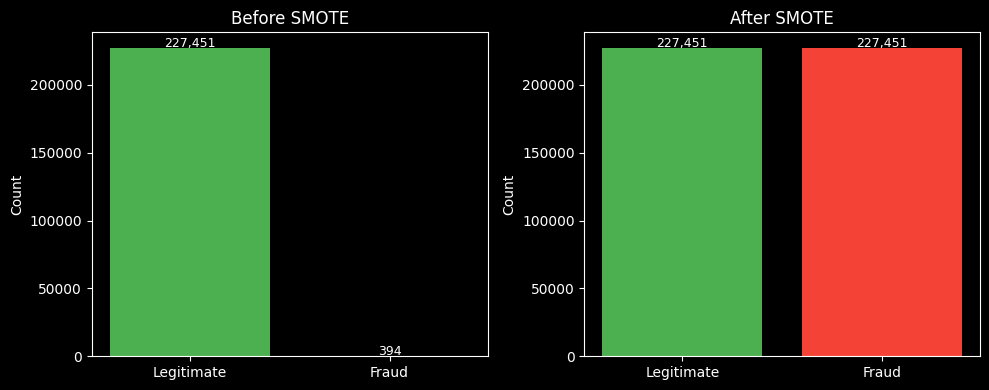

In [8]:
print('Before SMOTE:')
print(f'  Legitimate: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Legitimate: {(y_train_sm==0).sum():,} | Fraud: {(y_train_sm==1).sum():,}')
print(f'  Total: {len(X_train_sm):,} samples')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['Legitimate', 'Fraud'], counts.values, color=['#4CAF50', '#F44336'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Baseline — Logistic Regression

In [9]:
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('\n=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'AUPRC:    {average_precision_score(y_test, y_prob_lr):.4f}')

Training Logistic Regression...

=== Logistic Regression Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC:  0.9700
AUPRC:    0.7146


## 4. Main Model — XGBoost

In [10]:
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('\n=== XGBoost Results ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'AUPRC:    {average_precision_score(y_test, y_prob_xgb):.4f}')

# Save model
joblib.dump(xgb, f'{MODELS_DIR}/xgb_model.pkl')
print(f'\nModel saved to {MODELS_DIR}/xgb_model.pkl')

Training XGBoost...
[0]	validation_0-logloss:0.65106
[50]	validation_0-logloss:0.10083
[100]	validation_0-logloss:0.05229
[150]	validation_0-logloss:0.03484
[200]	validation_0-logloss:0.02544
[250]	validation_0-logloss:0.01828
[299]	validation_0-logloss:0.01364

=== XGBoost Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.37      0.87      0.52        98

    accuracy                           1.00     56962
   macro avg       0.68      0.93      0.76     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:  0.9799
AUPRC:    0.8508

Model saved to /content/models/xgb_model.pkl


## 5. Model Comparison — Confusion Matrices

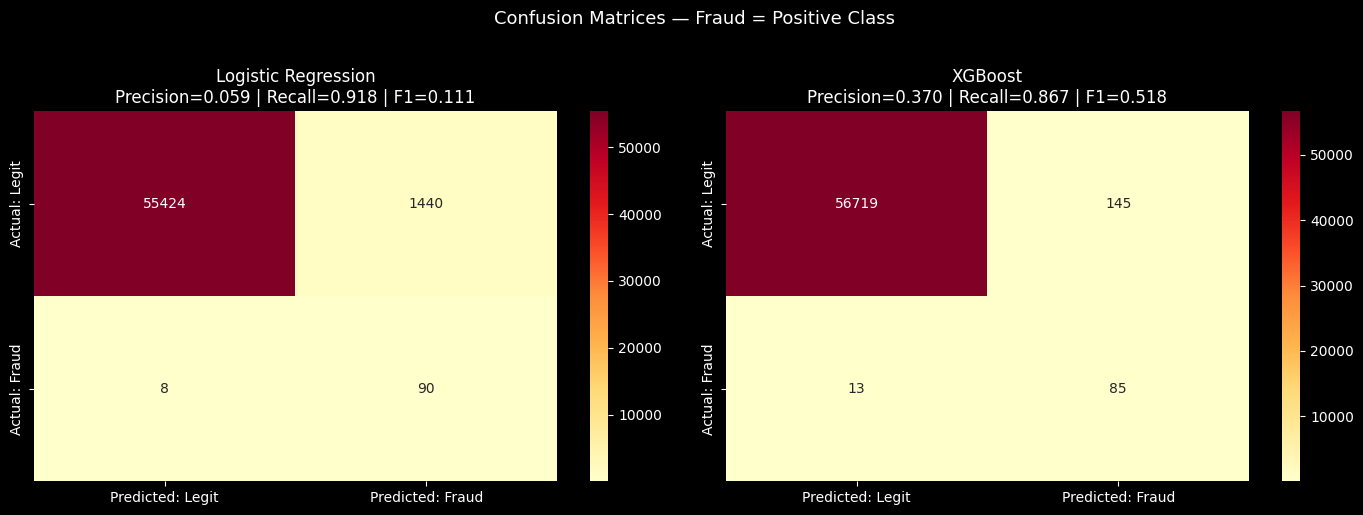

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, ax=ax, annot=True, fmt='d', cmap='YlOrRd',
        xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
        yticklabels=['Actual: Legit', 'Actual: Fraud']
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{title}\nPrecision={precision_score(y_test,y_pred):.3f} '
        f'| Recall={recall_score(y_test,y_pred):.3f} '
        f'| F1={f1_score(y_test,y_pred):.3f}'
    )

plt.suptitle('Confusion Matrices — Fraud = Positive Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC Curve & Precision-Recall Curve

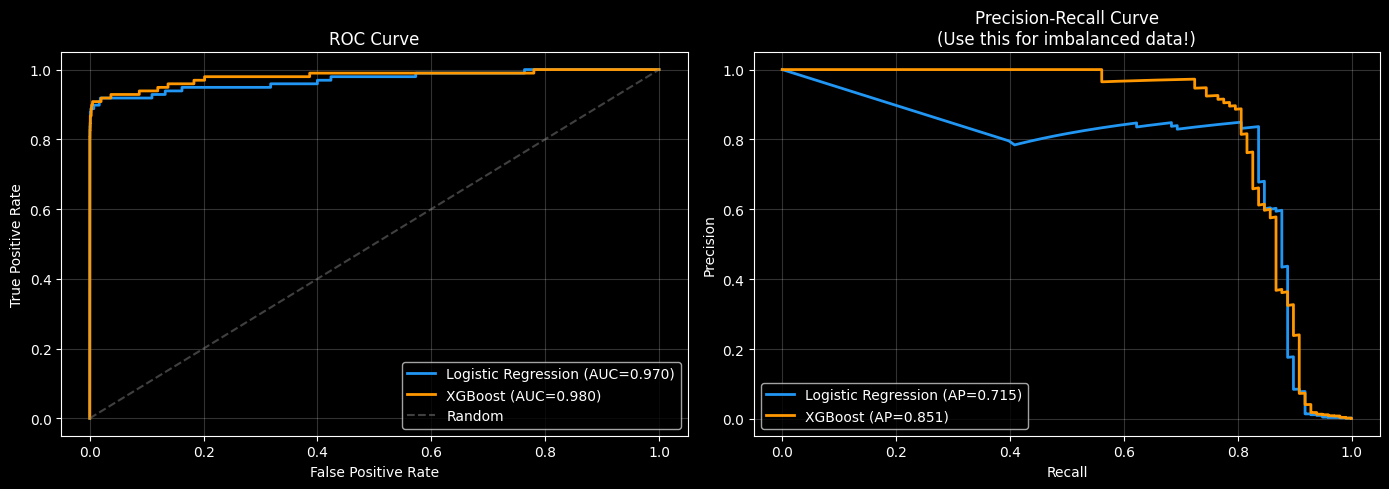

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#2196F3'),
    (y_prob_xgb, 'XGBoost', '#FF9800')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Precision-Recall Curves (more meaningful for imbalanced data)
for prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#2196F3'),
    (y_prob_xgb, 'XGBoost', '#FF9800')
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f'{label} (AP={ap:.3f})', color=color, linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\n(Use this for imbalanced data!)')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Results Summary

In [13]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Precision': [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_xgb), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_xgb), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_xgb), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ],
    'AUPRC': [
        round(average_precision_score(y_test, y_prob_lr), 4),
        round(average_precision_score(y_test, y_prob_xgb), 4)
    ]
})

print('=== FINAL MODEL COMPARISON ===')
print(results.to_string(index=False))
print(f'\n✅ XGBoost model saved to {MODELS_DIR}/xgb_model.pkl')
print(f'✅ Scaler saved to {MODELS_DIR}/scaler.pkl')
print('\nNext step: Run 03_shap_explainability.ipynb')

=== FINAL MODEL COMPARISON ===
              Model  Precision  Recall  F1-Score  ROC-AUC  AUPRC
Logistic Regression     0.0588  0.9184    0.1106   0.9700 0.7146
            XGBoost     0.3696  0.8673    0.5183   0.9799 0.8508

✅ XGBoost model saved to /content/models/xgb_model.pkl
✅ Scaler saved to /content/models/scaler.pkl

Next step: Run 03_shap_explainability.ipynb
